# Introduction - Freelancer Gig Success Analysis

The freelance economy is growing rapidly, and platforms like Upwork, Fiverr, and Freelancer.com have created massive opportunities for remote professionals worldwide.

In this notebook, we will explore a synthetic yet realistic dataset containing freelancer profile details, skills, earnings, response behavior, and performance metrics.

### Goals of This Notebook
- Understand freelancer demographics
- Analyze factors affecting freelancer success
- Explore earnings patterns
- Discover relationships between experience, skills, and success score
- Visualize important trends using Python libraries

# 1. Import Libraries and load dataset

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sarveshchhetri/freelancer-success-earnings-and-churn-prediction/freelancer_gig_success_dataset.csv


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

In [ ]:
df = pd.read_csv('freelancer_gig_success_dataset.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (12000, 20)


,freelancer_id,age,gender,country,years_experience,num_skills,profile_completeness,has_portfolio,has_video_profile,has_certifications,primary_skill,hourly_rate_usd,total_jobs_completed,job_success_rate,repeat_client_rate,avg_response_time_hrs,total_earnings_12m_usd,success_score,churn_risk,earnings_tier
0,FL_000000,27,Female,United Kingdom,3.3,15,51.4,1,0,1.0,Web Development,231.26,24,100.0,0.327,15.1,71463,82.2,0,High
1,FL_000001,40,Male,United States,4.8,4,61.7,0,1,0.0,Data Science & Analytics,201.14,30,51.6,0.219,23.8,106008,72.2,0,High
2,FL_000002,49,Female,Other,1.6,12,100.0,1,1,1.0,Video Editing,280.00,36,96.0,0.327,12.7,21720,89.0,0,High
3,FL_000003,35,Female,United States,6.1,11,99.9,1,0,0.0,Data Science & Analytics,188.89,42,100.0,0.222,21.4,245000,91.8,0,High
4,FL_000004,31,Male,United States,2.2,7,81.9,1,1,1.0,Video Editing,280.00,27,87.2,0.350,4.7,108821,79.8,0,High


# 2. Exploratory Data Analysis

### Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   freelancer_id           12000 non-null  object 
 1   age                     12000 non-null  int64  
 2   gender                  12000 non-null  object 
 3   country                 12000 non-null  object 
 4   years_experience        12000 non-null  float64
 5   num_skills              12000 non-null  int64  
 6   profile_completeness    12000 non-null  float64
 7   has_portfolio           12000 non-null  int64  
 8   has_video_profile       12000 non-null  int64  
 9   has_certifications      11981 non-null  float64
 10  primary_skill           12000 non-null  object 
 11  hourly_rate_usd         11174 non-null  float64
 12  total_jobs_completed    12000 non-null  int64  
 13  job_success_rate        11156 non-null  float64
 14  repeat_client_rate      11254 non-null

In [ ]:
df.describe()

,age,years_experience,num_skills,profile_completeness,has_portfolio,has_video_profile,has_certifications,hourly_rate_usd,total_jobs_completed,job_success_rate,repeat_client_rate,avg_response_time_hrs,total_earnings_12m_usd,success_score,churn_risk
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11981.000000,11174.000000,12000.000000,11156.000000,11254.000000,11165.000000,12000.000000,12000.000000,12000.00000
mean,36.128667,3.775267,9.505167,78.458050,0.695417,0.323083,0.426175,242.384341,30.317667,85.999973,0.330772,13.972297,131492.886833,83.547083,0.09750
std,8.915524,3.748644,3.447651,14.587711,0.460250,0.467674,0.494540,61.278244,8.281524,9.715777,0.101573,6.302759,75855.648733,10.846722,0.29665
min,21.000000,0.000000,4.000000,40.000000,0.000000,0.000000,0.000000,22.970000,9.000000,48.300000,0.047000,1.400000,2938.000000,42.500000,0.00000
25%,28.000000,1.100000,7.000000,68.300000,0.000000,0.000000,0.000000,214.272500,25.000000,79.300000,0.259000,9.400000,65875.000000,75.800000,0.00000
50%,36.000000,2.600000,9.000000,79.100000,1.000000,0.000000,0.000000,280.000000,29.000000,86.600000,0.328000,13.000000,117566.000000,83.900000,0.00000
75%,44.000000,5.300000,12.000000,89.900000,1.000000,1.000000,1.000000,280.000000,35.000000,93.600000,0.400000,17.400000,203314.750000,92.300000,0.00000
max,51.000000,20.000000,15.000000,100.000000,1.000000,1.000000,1.000000,280.000000,70.000000,100.000000,0.681000,59.400000,245000.000000,99.000000,1.00000


In [ ]:
df.isnull().sum()

freelancer_id               0
age                         0
gender                      0
country                     0
years_experience            0
num_skills                  0
profile_completeness        0
has_portfolio               0
has_video_profile           0
has_certifications         19
primary_skill               0
hourly_rate_usd           826
total_jobs_completed        0
job_success_rate          844
repeat_client_rate        746
avg_response_time_hrs     835
total_earnings_12m_usd      0
success_score               0
churn_risk                  0
earnings_tier               0
dtype: int64

### Distribution of Success Score

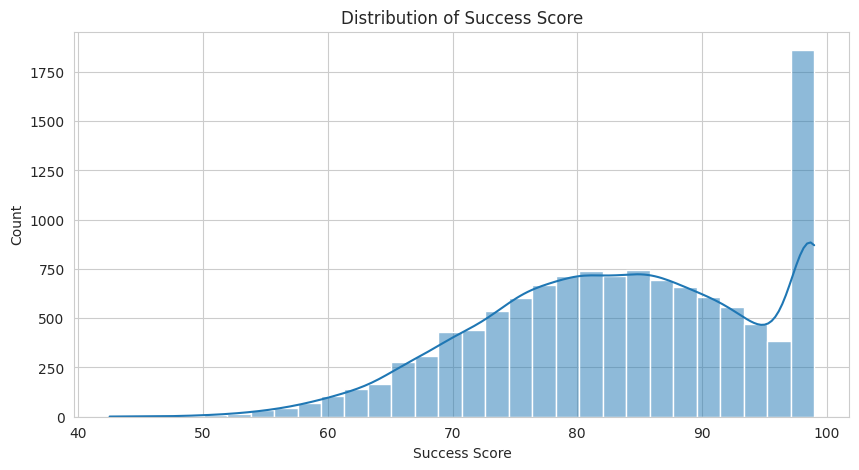

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['success_score'], bins=30, kde=True)
plt.title('Distribution of Success Score')
plt.xlabel('Success Score')
plt.ylabel('Count')
plt.show()

### Top Skills by Average Earnings

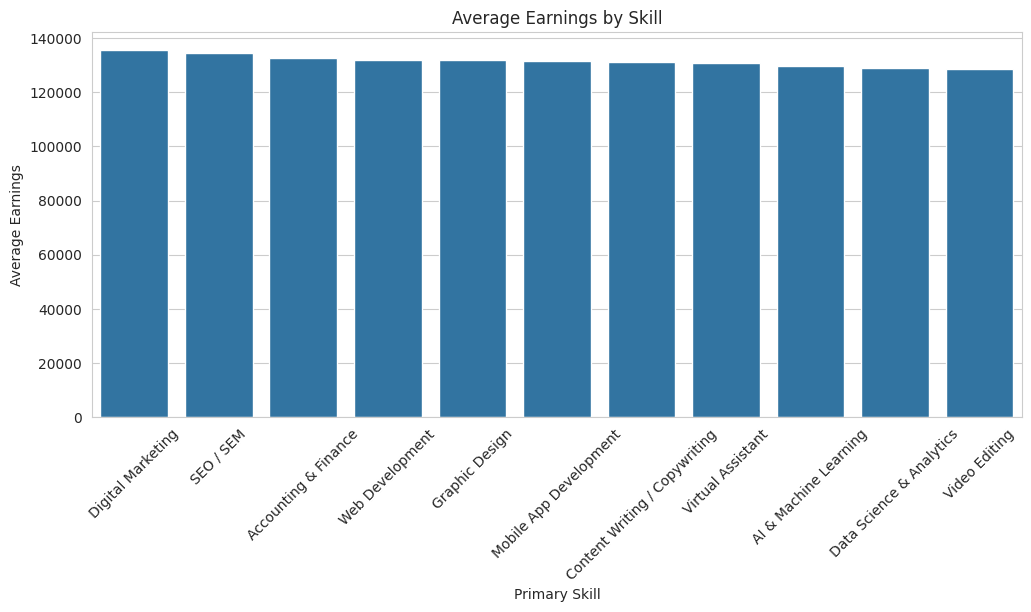

In [ ]:
top_skills = (df.groupby('primary_skill')['total_earnings_12m_usd'].mean().sort_values(ascending=False))
plt.figure(figsize=(12,5))
sns.barplot(x=top_skills.index, y=top_skills.values)
plt.title('Average Earnings by Skill')
plt.xlabel('Primary Skill')
plt.ylabel('Average Earnings')
plt.show()

### Experience vs Success Score

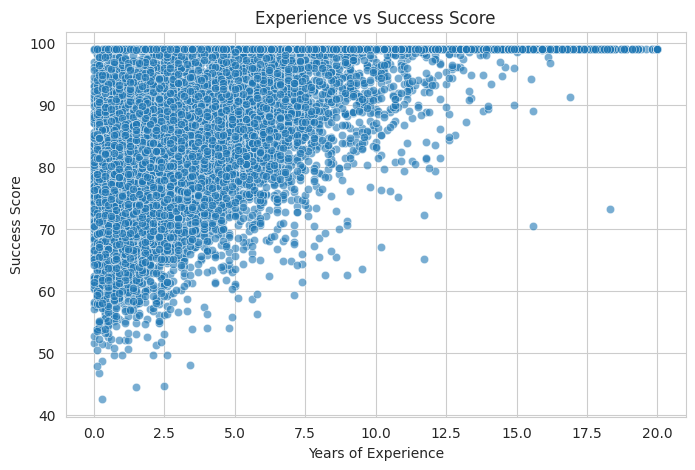

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='years_experience',y='success_score',alpha=0.6)
plt.title('Experience vs Success Score')
plt.xlabel('Years of Experience')
plt.ylabel('Success Score')
plt.show()

### Freelancer Distribution by Country

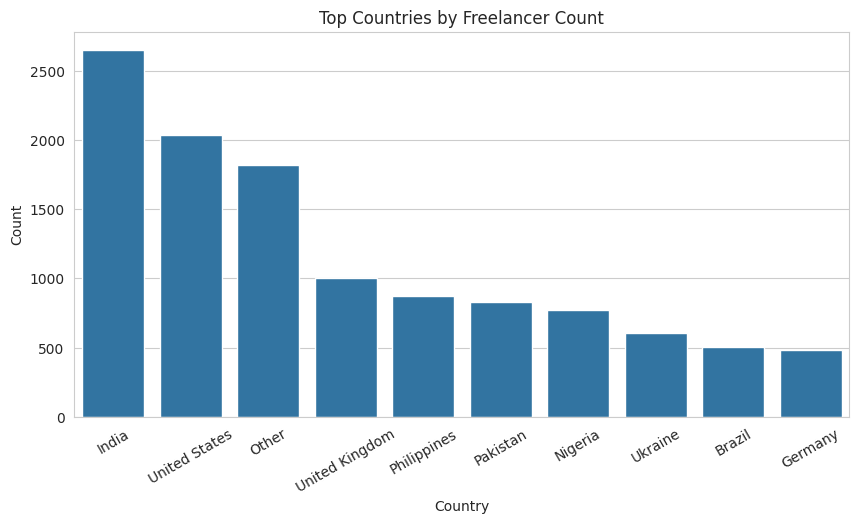

In [ ]:
country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Top Countries by Freelancer Count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

### Correlation Heatmap

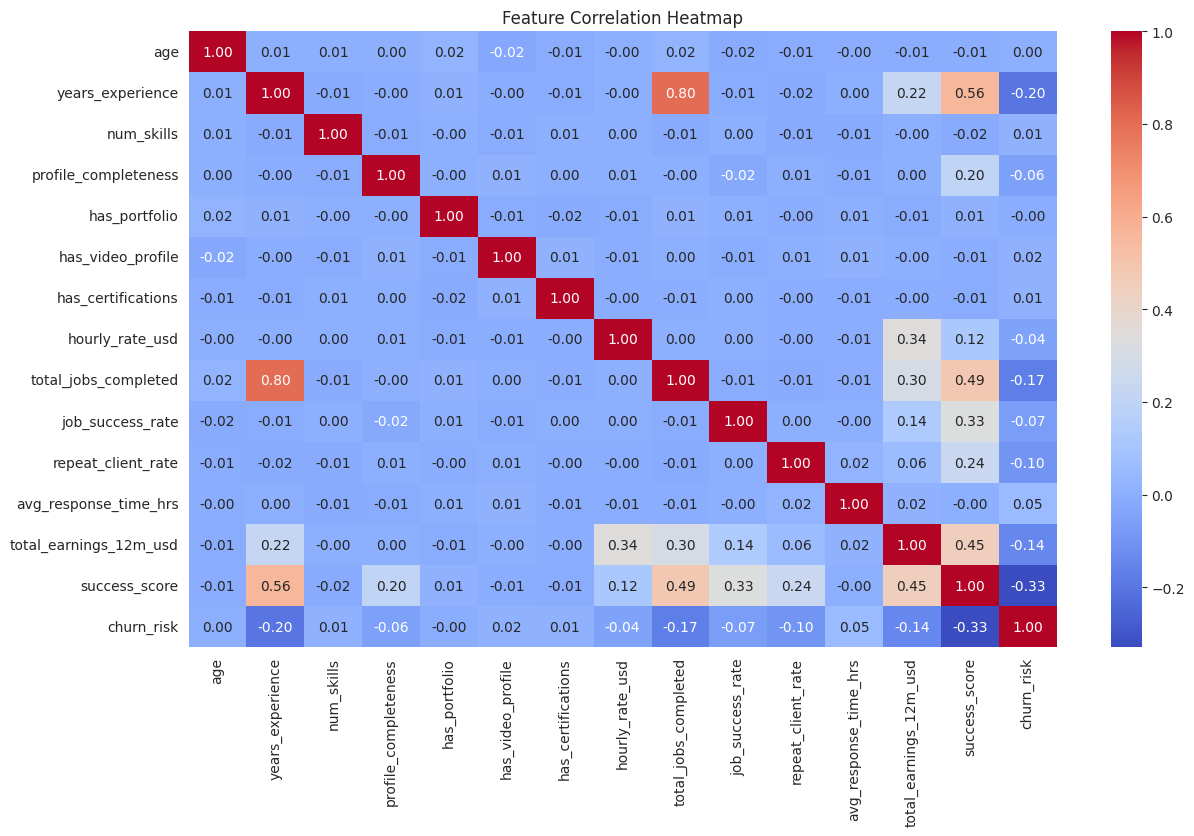

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### 🏆 Top 10 Highest Earning Freelancers

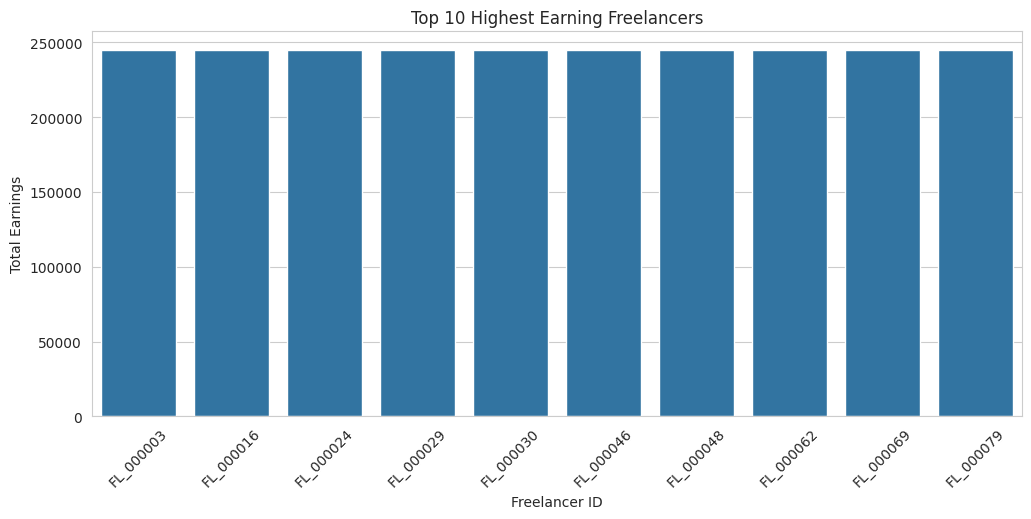

In [ ]:
top_freelancers = df.nlargest(10, 'total_earnings_12m_usd')

plt.figure(figsize=(12,5))
sns.barplot(x='freelancer_id',y='total_earnings_12m_usd', data=top_freelancers)
plt.title('Top 10 Highest Earning Freelancers')
plt.xlabel('Freelancer ID')
plt.ylabel('Total Earnings')
plt.show()

# 3. Model taining and Evaluation

In [ ]:
ml_df = df.copy()

# encode categorical columns
for col in ml_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])

# features and target
X = ml_df.drop('success_score', axis=1)
y = ml_df['success_score']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# predictions
preds = model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, preds)
print('MAE:', round(mae, 2))

MAE: 5.3


# 4. Feature Importance

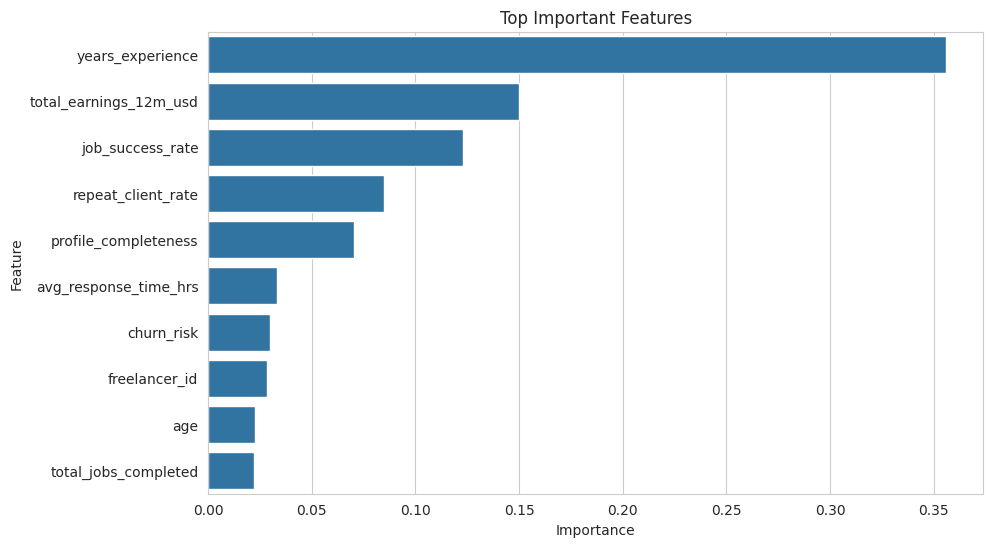

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10),x='Importance',y='Feature')
plt.title('Top Important Features')
plt.show()

# 5. Conclusion
In this notebook, we explored freelancer performance and earnings trends using exploratory data analysis and machine learning.

**Key Findings**
- Experience positively impacts freelancer success.
- Skill specialization plays a major role in earnings.
- Faster response times may improve client satisfaction.
- Success score is influenced by multiple interconnected factors.
